In [181]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

In [182]:
import os
os.makedirs("outputs", exist_ok=True)

In [183]:
import torch
import torchvision
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path
import random

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cpu
PyTorch version:     2.10.0+cpu
TorchVision version: 0.25.0+cpu


## PyTorch

### Q1

In [184]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

print(a)
print("Shape a:", a.shape)
print("Type a:", a.dtype)
print("Device a:", a.device)
print(b)
print("Shape b:", b.shape)
print("Type b:", b.dtype)
print("device b:", b.device)
print(c)
print("Shape c:", c.shape)
print("Type c:", c.type)
print("device c:", c.device)

tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape a: torch.Size([2, 3])
Type a: torch.float32
Device a: cpu
tensor([[0., 0., 0.],
        [0., 0., 0.]])
Shape b: torch.Size([2, 3])
Type b: torch.float32
device b: cpu
tensor([1., 1., 1., 1.])
Shape c: torch.Size([4])
Type c: <built-in method type of Tensor object at 0x7d2007adc050>
device c: cpu


### The tensors right now are in the CPU. When running on the GPU, the model weights and the tensors are on the same device because a the weights are part of the neuron and the weights are part of the activation function.

### Q2

In [185]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])
x_sqrt = torch.sqrt(x)
print("x_sqrt:", x_sqrt)

x_sum = print("x_sum:", x.sum())
x_mean = print("x_mean:", x.mean())
x_argmax = print("x_argmax:", x.argmax())


x_sqrt: tensor([1., 2., 3., 4., 5.])
x_sum: tensor(55.)
x_mean: tensor(11.)
x_argmax: tensor(4)


.argmax() appears in nearly every inference example you'll encounter. In the context of a classifier that outputs scores for 1,000 classes, what does .argmax() give you? The function argmax returns the position of the max tensor.

### Q3

In [186]:
a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

a_gpu device: cpu
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


Add a comment: why does PyTorch require .cpu() before you can call .numpy()? What does this tell you about where NumPy arrays live? it requieres .cpu() because to run numpy needs to be in cpu an not in gpu.

### Q4

In [187]:
t = torch.arange(24).float()

reshape_1 = t.reshape(4, 6)
print("Shape (4,6):",reshape_1.shape)

reshape_2 = t.reshape(2, 3, 4)
print("Shape (2,3,4):", reshape_2.shape)

new_shape_1= reshape_1.unsqueeze(0)
print("New dimension:", new_shape_1.shape)

Shape (4,6): torch.Size([4, 6])
Shape (2,3,4): torch.Size([2, 3, 4])
New dimension: torch.Size([1, 4, 6])


Add a comment: a single image tensor typically has shape (channels, height, width). Neural networks expect batches with shape (batch_size, channels, height, width). What operation accomplishes this when you are processing one image at a time, and why does it matter?  When processing one image at a time we use unsqueeze(0) to add a batch dimension.

### Q5

In [188]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

np_matrix = np.matmul(np_a, np_b)
print("NumPy mult:", np_matrix)

pt_matrix = torch.matmul(t_a, t_b)
print("PyTorch mult:", pt_matrix)

NumPy mult: [[19. 22.]
 [43. 50.]]
PyTorch mult: tensor([[19., 22.],
        [43., 50.]])


Add a comment: at a high level, what role does matrix multiplication play as data passes through a single layer of a neural network? the matrix multiplication allows mix information from all the freatures and as a result gives one output.

## Pretrained Models

### Model Q1

In [189]:
import torch
from torchvision import models
from torchvision.models import ResNet18_Weights

In [190]:
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

In [191]:
model = model.to(device)

In [192]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     11,689,512
Trainable parameters: 11,689,512


Add a comment: ResNet18 has roughly 11 million parameters. Training it from scratch required approximately 1.2 million labeled ImageNet images and days of multi-GPU compute. What does that tell you about the practical value of starting from pretrained weights when you're on a deadline or a budget?  Pretrained models skips all the millions of labeled images and days of GPU time.

### Model Q2

In [193]:
# Print the full model architecture by running print(model). Read through the output — it shows every layer and its configuration.

# Then answer the following in comments:
# What is the name of the final layer in ResNet18, and what is its output size? (This number is the total count of ImageNet categories the model can predict.)
# Can you identify the blocks named layer1 through layer4? These are the "deep" part of the network — the feature extractor. In plain terms, what does it mean for a network to be "deep"?

In [194]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### The final layer is "fc" for cully connected layer.  The output is 1000 features or categories. 

#### A network "deep" it's in terms of the layers that has.  What it means thateach layer has diferent features, layer 1 has lines or edges, the layer 2 could have patterns and so on, the lasy layer has objects.  So if a network is more deep has more information to represent the final output.


### Model Q3

In [195]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

Model ready for inference.


#### Add a comment explaining each line:

#### What does .to(device) do, and why does it need to match the device your input tensors will be on? What does model.eval() change about the model's behavior? Name at least one layer type that behaves differently in training mode vs. evaluation mode. 
To device switches from GPU to CPU and the model.eval() checks or evaluates if the model is ready for inference

### Model Q4

In [196]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)



1. What does the resize/crop step accomplish? With resize and crop we accomplish that all the images have the same size.  All neural networks expect fixed size inputs.
2. What does ToTensor() do to the pixel value range? Scales pixel values.  It helps to normalize the values, neural networks work better with normalized values.
3. What is normalization doing, and why does it use ImageNet's specific mean and standard deviation values rather than, say, mean=0.5, std=0.5? normalization adjust the pixel values.  The model was trained on ImageNet images so uses the mean and standar dewviation from ImageNet, if we set the values would change the model accuracy.


## Running Inference

In [197]:
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

In [198]:
imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


### Inference Q1

In [199]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)

BASE_DIR = Path(path)

Path to dataset files: /kaggle/input/datasets/puneet6060/intel-image-classification


In [200]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

print("DATA_DIR exists:", DATA_DIR.exists())
print("DATA_DIR:", DATA_DIR)

for label in LABELS:
    class_dir = DATA_DIR / label
    image_files = list(class_dir.glob("*.jpg"))
    print(label, "exists:", class_dir.exists(), "jpg count:", len(image_files))

DATA_DIR exists: True
DATA_DIR: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test
buildings exists: True jpg count: 437
forest exists: True jpg count: 474
glacier exists: True jpg count: 553
mountain exists: True jpg count: 525
sea exists: True jpg count: 510
street exists: True jpg count: 501


In [201]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """

    # Step 1: Preprocess image, add batch dimension, move to device
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)   # shape: (1, 1000)

    # Step 3: Convert logits to probabilities
    probabilities = F.softmax(output[0], dim=0)

    # Step 4: Get top 5 predictions
    top_probs, top_indices = torch.topk(probabilities, 5)

    # Step 5: Build list of tuples
    predictions = []
    for prob, idx in zip(top_probs, top_indices):
        class_name = class_labels[idx.item()]
        predictions.append((class_name, prob.item()))

    return predictions

In [202]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")



Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


#### Add a comment: does the top prediction make sense? Remember that the model was trained on ImageNet's 1,000 categories, which include things like "alp", "valley", and "lakeside" rather than simply "mountain". Do any of the top-5 labels map onto what you'd describe as a mountain scene?  
The predictions make sense.   The top-5 categories map the scene of a mountain because there is no a mountaun label.


### Inference Q2

In [203]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


#### Add a comment: which classes does the model seem most confident about (high top-1 probability)? Which does it seem least confident about? Is there a pattern?  
The model is more confident when the image have more patterns or objects, like forest or buildings.  Is less confident when are large scenes like mountains because ImagNet focus more on objects than scenes.  We can see on the results that is more confident on a mountain than a street or a sea


### Inference Q3

In [204]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


#### Add a comment: why do neural networks output logits internally rather than probabilities? In a production pipeline that needs to filter out low-confidence predictions, which representation would you work with — logits or probabilities — and why? 
The neural networks output logits because they are numerically stable.  I will work with probabilities because they are more stable.  
In a production pipeline that needs to filter out low confidence predictions, is better to work with probabilities because they compare a range, like we saw the result between 0.000001 and 0.0979

### Inference Q4

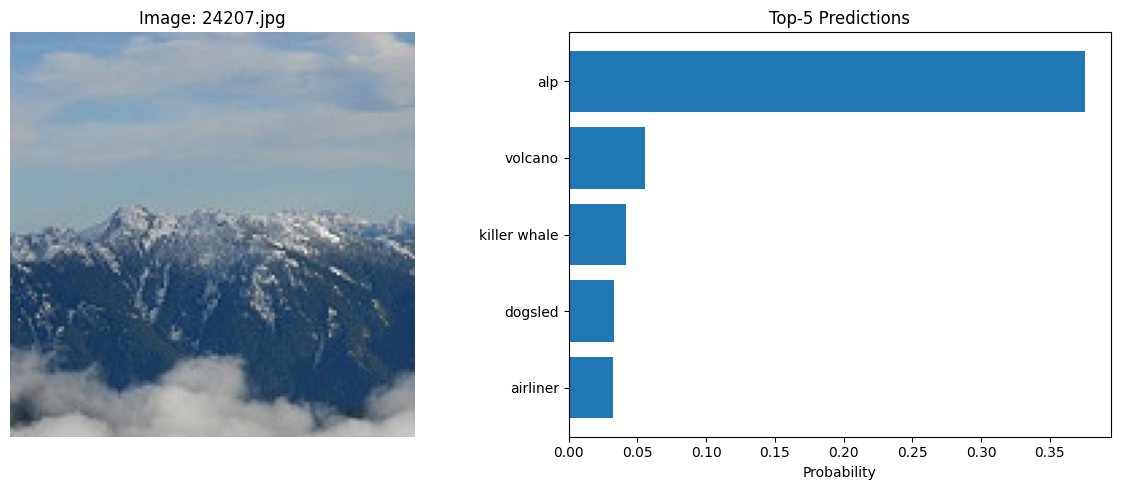

In [205]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

class_names = [class_name for class_name, prob in preds]
probabilities = [prob for class_name, prob in preds]

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].set_title(f"Image: {img_name}")
axes[0].axis("off")

axes[1].barh(class_names, probabilities)
axes[1].invert_yaxis()
axes[1].set_xlabel("Probability")
axes[1].set_title("Top-5 Predictions")

plt.tight_layout()
plt.savefig(output_dir / "warmup_inference_viz.png", dpi=150, bbox_inches="tight")
plt.show()


#### Add a comment: how would you adapt this kind of visualization for a dashboard that a non-technical team member needs to review flagged predictions? What threshold on the top-1 probability might you use to decide when a prediction is "confident enough" to act on?
I will use the graph because is noticiable the result with higher probability and is easy to explain and compare.  To decide if a prediction is confident enough it will have to be above .80 because is a significant result.